In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os


In [2]:
import cv2 
import os 

In [3]:
import matplotlib.pyplot as plt


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Found 0 images belonging to 0 classes.


IndexError: index 0 is out of bounds for axis 0 with size 0

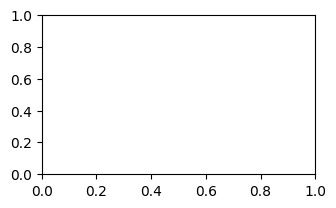

In [6]:
def dataset_train_processing():
    # Hardcode dataset path
    data_path =r'C:\SumMe\Frame\Base jumping'
    augmented_data_path = r'C:\SumMe\Augmentation\AugB\Aug'
    
    # Create the directory for augmented data if it doesn't exist
    if not os.path.exists(augmented_data_path):
        os.makedirs(augmented_data_path)
    
    # Process dataset
    file_names = os.listdir(data_path)
    
    # Set a datagenerator for augmentation
    train_datagen = ImageDataGenerator(rotation_range=15,
                                       shear_range=0.1,
                                       zoom_range=0.2,
                                       horizontal_flip=True,
                                       width_shift_range=0.1,
                                       height_shift_range=0.1)
    
    # Create batches of data for augmentation
    for file_name in file_names:
        image_path = os.path.join(data_path, file_name)
        img = plt.imread(image_path)
        img = img.reshape((1,) + img.shape)  # Reshape to add batch dimension
        
        # Flow the image through the generator and save augmented images
        i = 0
        for batch in train_datagen.flow(img, 
                                        batch_size=1,
                                        save_to_dir=augmented_data_path,
                                        save_prefix=f'aug_{os.path.splitext(file_name)[0]}',
                                        save_format='jpeg'):
            i += 1
            if i >= 1:  # Save 2 augmented versions of each image
                break
    
    # Sample visualization of augmented images (optional)
    example_gen = train_datagen.flow_from_directory(data_path,
                                                    target_size=(224, 224),
                                                    batch_size=1,
                                                    class_mode=None,
                                                    save_to_dir=augmented_data_path,
                                                    save_prefix='aug_example',
                                                    save_format='jpg')
    
    plt.figure(figsize=(12, 12))
    for i in range(0, 15):
        plt.subplot(5, 3, i + 1)
        for X in example_gen:
            image = X[0]
            plt.imshow(image)
            break
    plt.tight_layout()
    plt.show()

# Usage
dataset_train_processing()

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
import numpy as np
import os

# Load the InceptionV3 model
net = InceptionV3(include_top=True, weights='imagenet')
net.summary()

# Load images from directory using ImageDataGenerator
image_directory = r'C:\SumMe\Augmentation\AugB'
input_size = net.input_shape[1:3]  # Get the input size (height, width)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Create a data generator for the images
augimds = datagen.flow_from_directory(image_directory,
                                      target_size=input_size,
                                      batch_size=32,  # Adjust the batch size if needed
                                      class_mode=None,
                                      shuffle=False) 

# Create a model that outputs the activations from the specified layer
layer_name = 'predictions'  # Example layer name in InceptionV3 (change as needed)
intermediate_layer_model = tf.keras.Model(inputs=net.input,
                                          outputs=net.get_layer(layer_name).output)

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Reshape the features to ensure they are in 'rows' format (2D)
features_train = features_train.reshape(features_train.shape[0], -1)
np.save(os.path.join(image_directory, 'inceptionv3_features_train.npy'), features_train)

print(f"Features shape: {features_train.shape}")

# Print some sample features
print("Sample features (first 5 rows):")
print(features_train[:5])

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 149, 149, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 149, 149, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                      

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os


# Load the ResNet50 model
net = ResNet50(include_top=True, weights='imagenet')
net.summary()

# Load images from directory using ImageDataGenerator
image_directory = r'C:\SumMe\Augmentation\AugB'
input_size = net.input_shape[1:3]  # Get the input size (height, width)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Create a data generator for the images
augimds = datagen.flow_from_directory(image_directory,
                                      target_size=input_size,
                                      batch_size=32,  # Adjust the batch size if needed
                                      class_mode=None,
                                      shuffle=False) 

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Create a model that outputs the activations from the specified layer
layer_name = 'predictions'  # Example layer name in ResNet50
intermediate_layer_model = tf.keras.Model(inputs=net.input,
                                          outputs=net.get_layer(layer_name).output)

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Reshape the features to ensure they are in 'rows' format (2D)
features_train = features_train.reshape(features_train.shape[0], -1)
np.save(os.path.join(image_directory, 'resnet50_features_train.npy'), features_train)


print(f"Features shape: {features_train.shape}")

# Print some sample features
print("Sample features (first 5 rows):")
print(features_train[:5])

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

In [10]:
import numpy as np
import os

# Define the directory where your features are saved
image_directory = r'C:\SumMe\Augmentation\AugB'

# Load the features from the saved .npy files
features_resnet = np.load(os.path.join(image_directory, 'resnet50_features_train.npy'))
features_inceptionv3 = np.load(os.path.join(image_directory, 'inceptionv3_features_train.npy'))

# Ensure both feature arrays have the same number of samples
assert features_resnet.shape[0] == features_inceptionv3.shape[0], "Number of samples must be the same in both feature arrays."

# Concatenate the features along the feature dimension (axis=1)
features_combined = np.concatenate((features_resnet, features_inceptionv3), axis=1)

# Save the combined features to a new .npy file
np.save(os.path.join(image_directory, 'combined_features_train.npy'), features_combined)

print(f"Combined features shape: {features_combined.shape}")

# Print some sample combined features
print("Sample combined features (first 5 rows):")
print(features_combined[:5])

Combined features shape: (4729, 2000)
Sample combined features (first 5 rows):
[[4.60012097e-06 8.36214967e-05 3.21908774e-05 ... 7.77023251e-06
  5.92068391e-05 9.13617350e-06]
 [1.27204157e-06 4.24497994e-05 3.45274711e-05 ... 6.38218189e-05
  5.27734737e-05 1.67662016e-04]
 [4.00007821e-07 6.48876585e-06 8.39173590e-05 ... 2.21424471e-05
  2.71406479e-05 1.19166405e-04]
 [7.76031629e-06 4.21957920e-05 1.25494744e-05 ... 1.48941181e-04
  1.35281807e-04 4.93151776e-04]
 [9.29074304e-06 1.74803805e-04 9.54605639e-05 ... 3.61389721e-05
  9.64447099e-05 2.08478668e-04]]


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [6]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Define the directory where your features are saved
image_directory = r'C:\SumMe\Augmentation\AugB'

# Load the features from the saved .npy files
features_combined = np.load(os.path.join(image_directory, 'combined_features_train.npy'))

# Define the number of timesteps (sequence length) and features
timesteps = 1  # Assuming each sample is treated as a sequence of length 1 for this example
input_dim = features_combined.shape[1]  # Should be 2000

# Prepare data for LSTM
# For this example, we'll use the features directly as sequences of length 1
X = features_combined
y = np.random.randint(0, 100, size=(features_combined.shape[0],))  # Example target variable, replace with your actual labels

# Reshape input to be [samples, timesteps, features]
X = X.reshape((X.shape[0], timesteps, input_dim))

# Define the LSTM model
inputs = Input(shape=(timesteps, input_dim))

# Add LSTM layers
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.5)(x)

x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(32)(x)
x = Dropout(0.5)(x)

# Add a Dense layer for output
outputs = Dense(100, activation='softmax')(x)  # Adjust the number of units based on your specific task

# Create the model
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Train the model
# For this example, we use dummy targets. Replace y with your actual labels.
model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2)

# Extract features from the last LSTM layer
feature_extractor = Model(inputs=model.input, outputs=model.layers[-3].output)  # Layer before the final Dense layer

# Obtain features from the last LSTM layer
features_last_lstm = feature_extractor.predict(X)

# Save the extracted features
np.save(os.path.join(image_directory, 'features_last_lstm.npy'), features_last_lstm)

# Print the feature shape
print(f"Shape of features extracted from the last LSTM layer: {features_last_lstm.shape}")

# Print some sample features
print("Sample features from the last LSTM layer (first 5 samples):")
print(features_last_lstm[:5])

Epoch 1/20
119/119 [==============================] - 60s 142ms/step - loss: 4.6052 - accuracy: 0.0111 - val_loss: 4.6053 - val_accuracy: 0.0116
Epoch 2/20
119/119 [==============================] - 8s 71ms/step - loss: 4.6031 - accuracy: 0.0143 - val_loss: 4.6053 - val_accuracy: 0.0116
Epoch 3/20
119/119 [==============================] - 9s 72ms/step - loss: 4.6015 - accuracy: 0.0151 - val_loss: 4.6062 - val_accuracy: 0.0116
Epoch 4/20
119/119 [==============================] - 8s 71ms/step - loss: 4.6000 - accuracy: 0.0140 - val_loss: 4.6071 - val_accuracy: 0.0116
Epoch 5/20
119/119 [==============================] - 8s 64ms/step - loss: 4.5989 - accuracy: 0.0140 - val_loss: 4.6081 - val_accuracy: 0.0116
Epoch 6/20
119/119 [==============================] - 8s 69ms/step - loss: 4.5976 - accuracy: 0.0153 - val_loss: 4.6096 - val_accuracy: 0.0116
Epoch 7/20
119/119 [==============================] - 8s 70ms/step - loss: 4.5966 - accuracy: 0.0140 - val_loss: 4.6087 - val_accuracy: 0.01

In [8]:
import numpy as np
from sklearn.cluster import KMeans

# Load data (assuming the data is saved in a numpy array .npy file)
# Replace the path with the actual location of your data file
F = np.load(r"C:\SumMe\Augmentation\AugB\features_last_lstm.npy")  # Adjust this path if necessary

# Set parameters
N = 709
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Initialize list to store indices of data points in each cluster
C = {i: np.where(C_IDX == i)[0] for i in range(N)}

# C now contains the indices of data points in each cluster

In [9]:
# Print the actual data points in the first cluster (cluster 0)
cluster_0_data_points = F[C[0], :]
print(cluster_0_data_points)

[[ 0.04453465  0.02115363 -0.02925223  0.01153691  0.0135715  -0.06118637
  -0.03209253 -0.03505411  0.01834477 -0.02830021 -0.02710652  0.0226183
   0.0364005   0.01936866 -0.03840059  0.03778966  0.03161189  0.01043842
   0.02022645 -0.05571473 -0.00496065 -0.03043812 -0.07324562 -0.02523634
  -0.02630531  0.04137516  0.03465216 -0.04447478 -0.04126612  0.02743137
   0.0284421  -0.02639938]
 [ 0.04468473  0.02052598 -0.02896416  0.01145506  0.01327825 -0.06141372
  -0.03199164 -0.03559202  0.01788433 -0.02844297 -0.02753697  0.0224616
   0.03692787  0.01924374 -0.0386006   0.03776873  0.0320339   0.01020239
   0.0194882  -0.05606418 -0.00480708 -0.03087609 -0.07390359 -0.02587749
  -0.0260115   0.04196153  0.03459113 -0.04493206 -0.04202088  0.02742926
   0.02839902 -0.02662523]
 [ 0.04509902  0.02100867 -0.02992727  0.01139692  0.01298618 -0.06215005
  -0.03251129 -0.03576314  0.01866626 -0.02871245 -0.02787569  0.02270531
   0.03739773  0.01897836 -0.03885641  0.03829346  0.0320906

In [10]:
# Print all the indices and their corresponding cluster values
for cluster_idx in range(N):
    print(f"Cluster {cluster_idx}:")
    print("Indices of data points:", C[cluster_idx])
    print("Number of data points in this cluster:", len(C[cluster_idx]))
    print()

Cluster 0:
Indices of data points: [1206 1766 2061 2585 3138]
Number of data points in this cluster: 5

Cluster 1:
Indices of data points: [ 882  995 1556 1856 2630]
Number of data points in this cluster: 5

Cluster 2:
Indices of data points: [2168 3253 3427 3944 3979 4666]
Number of data points in this cluster: 6

Cluster 3:
Indices of data points: [  45  223  416  543  637  654  657  696  726  752  990 1080 1301 1391
 1580 1740 1889 2210 2242 2301 2446 2459 4237 4327 4661 4698]
Number of data points in this cluster: 26

Cluster 4:
Indices of data points: [2093 2822 3536]
Number of data points in this cluster: 3

Cluster 5:
Indices of data points: [2135 2809 2847 3495 4072]
Number of data points in this cluster: 5

Cluster 6:
Indices of data points: [ 499  662  732 1343 1348 1371 1593 1864 2190 2203 2347 2413 3040 4551]
Number of data points in this cluster: 14

Cluster 7:
Indices of data points: [ 751 2147 3846 3861 3953]
Number of data points in this cluster: 5

Cluster 8:
Indices o

In [11]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# Load data (assuming the data is saved in a numpy array .npy file)
try:
    F = np.load(r"C:\SumMe\Augmentation\AugB\features_last_lstm.npy")  # Adjust this path if necessary
except FileNotFoundError:
    print("Error: The specified file was not found.")
    exit(1)

# Set parameters
N = 709 # Number of clusters
num_samples = F.shape[0]  # Number of data points (950)
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Initialize binary matrix (950 x 143) with zeros
keyframe_matrix = np.zeros((num_samples, N), dtype=int)

# Loop through each cluster and find the closest data point to the centroid
for cluster_idx in range(N):
    # Get the indices of the data points in the current cluster
    cluster_indices = np.where(C_IDX == cluster_idx)[0]
    
    # Skip empty clusters (if any)
    if len(cluster_indices) == 0:
        print(f"Cluster {cluster_idx} is empty, skipping.")
        continue
    
    # Get the feature vectors for the data points in this cluster
    cluster_features = F[cluster_indices, :]
    
    # Get the centroid of this cluster
    centroid = CC[cluster_idx]
    
    # Compute the Euclidean distance between each point in the cluster and the centroid
    distances = cdist(cluster_features, centroid.reshape(1, -1), metric='euclidean')
    
    # Get the index of the closest data point to the centroid
    closest_point_idx = cluster_indices[np.argmin(distances)]
    
    # Set the corresponding entry in the binary matrix to 1 (keyframe)
    keyframe_matrix[closest_point_idx, cluster_idx] = 1

    # Optionally, print the keyframe index for each cluster
    print(f"Cluster {cluster_idx}: Keyframe index: {closest_point_idx}")
# keyframe_matrix is now a 950 x 143 binary matrix
# You can use it for further analysis or saving to a file

Cluster 0: Keyframe index: 1766
Cluster 1: Keyframe index: 1556
Cluster 2: Keyframe index: 3944
Cluster 3: Keyframe index: 1391
Cluster 4: Keyframe index: 3536
Cluster 5: Keyframe index: 4072
Cluster 6: Keyframe index: 1371
Cluster 7: Keyframe index: 3953
Cluster 8: Keyframe index: 2882
Cluster 9: Keyframe index: 872
Cluster 10: Keyframe index: 56
Cluster 11: Keyframe index: 2160
Cluster 12: Keyframe index: 865
Cluster 13: Keyframe index: 3865
Cluster 14: Keyframe index: 1436
Cluster 15: Keyframe index: 4131
Cluster 16: Keyframe index: 3594
Cluster 17: Keyframe index: 2579
Cluster 18: Keyframe index: 4607
Cluster 19: Keyframe index: 3806
Cluster 20: Keyframe index: 2872
Cluster 21: Keyframe index: 3171
Cluster 22: Keyframe index: 3796
Cluster 23: Keyframe index: 4450
Cluster 24: Keyframe index: 2108
Cluster 25: Keyframe index: 2902
Cluster 26: Keyframe index: 3898
Cluster 27: Keyframe index: 3748
Cluster 28: Keyframe index: 2929
Cluster 29: Keyframe index: 1573
Cluster 30: Keyframe ind

In [12]:
# Save the keyframe binary matrix
np.save(r'C:\SumMe\Augmentation\AugB\keyframe.npy', keyframe_matrix)

In [13]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.io import savemat

# Load data (assuming the data is saved in a numpy array .npy file)
try:
    F = np.load(r"C:\SumMe\Augmentation\AugB\keyframe.npy")  # Adjust this path if necessary
except FileNotFoundError:
    print("Error: The specified file was not found.")
    exit(1)

# Check shape of input data
print("Shape of input data F:", F.shape)

# Set parameters
N = 709  # Number of clusters
num_samples = F.shape[0]  # Number of data points (should be 950)
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', n_init=50, random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Check cluster assignments
unique, counts = np.unique(C_IDX, return_counts=True)
cluster_sizes = dict(zip(unique, counts))
print("Cluster sizes:", cluster_sizes)

# Initialize binary matrix (950 x 143) with zeros
keyframe_matrix = np.zeros((num_samples, N), dtype=int)

# Loop through each cluster and find the closest data point to the centroid
for cluster_idx in range(N):
    # Get the indices of the data points in the current cluster
    cluster_indices = np.where(C_IDX == cluster_idx)[0]
    
    # Skip empty clusters (if any)
    if len(cluster_indices) == 0:
        print(f"Warning: Cluster {cluster_idx} is empty, skipping.")
        continue
    
    # Get the feature vectors for the data points in this cluster
    cluster_features = F[cluster_indices, :]
    
    # Get the centroid of this cluster
    centroid = CC[cluster_idx]
    
    # Compute the Euclidean distance between each point in the cluster and the centroid
    distances = cdist(cluster_features, centroid.reshape(1, -1), metric='euclidean')
    
    # Get the index of the closest data point to the centroid
    closest_point_idx = cluster_indices[np.argmin(distances)]
    
    # Set the corresponding entry in the binary matrix to 1 (keyframe)
    keyframe_matrix[closest_point_idx, cluster_idx] = 1

# Check the shape of the keyframe matrix
print("Shape of keyframe matrix:", keyframe_matrix.shape)

Shape of input data F: (4729, 709)
Cluster sizes: {0: 4021, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 1, 128: 1, 129: 1, 130: 1, 131: 1, 

In [1]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\AugB\features_last_lstm.npy")

# Step 2: (Optional) Preprocess the data if needed
# For example, you might want to scale the features to ensure the clustering works well
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 3: Perform Agglomerative Clustering
# You can specify the number of clusters or other hyperparameters here
n_clusters = 709  # Example, set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model to the feature matrix
clustering_labels = clustering.fit_predict(features_scaled)

# Step 4: (Optional) Visualize the results if the features are 2D (or use dimensionality reduction)
if features_scaled.shape[1] == 2:  # If your features are 2D, you can visualize them
    plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=clustering_labels, cmap='viridis')
    plt.title("Agglomerative Clustering Results")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# If you have higher-dimensional features, consider using PCA to reduce to 2D for visualization
# For example:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# features_2d = pca.fit_transform(features_scaled)
# plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clustering_labels, cmap='viridis')
# plt.show()

# Step 5: View the labels assigned to each data point
print("Cluster Labels:", clustering_labels)

Cluster Labels: [525 195 570 ... 379 237 106]


In [2]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\AugB\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters =709  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Display the clusters in the desired format
for cluster_label, indices in cluster_dict.items():
    print(f"Cluster {cluster_label}:")
    print(f"Indices of data points: {indices}")
    print(f"Number of data points in this cluster: {len(indices)}\n")

Cluster 525:
Indices of data points: [0, 297, 329, 457, 487, 910, 2330, 4211]
Number of data points in this cluster: 8

Cluster 195:
Indices of data points: [1, 107, 168, 221, 268, 448, 659, 1107, 1319, 1520, 1924, 2017, 2214, 2542, 4564, 4646]
Number of data points in this cluster: 16

Cluster 570:
Indices of data points: [2, 30, 124, 247, 402, 806, 1221, 1920, 2186, 2258, 2456, 4476, 4596, 4636, 4693]
Number of data points in this cluster: 15

Cluster 115:
Indices of data points: [3, 318, 503, 1104, 1358, 1386, 1622, 2639, 2687]
Number of data points in this cluster: 9

Cluster 73:
Indices of data points: [4, 729, 2345, 2640, 2953, 2956, 4117]
Number of data points in this cluster: 7

Cluster 442:
Indices of data points: [5, 189, 328, 424, 1409, 2254, 2373, 2623, 4209]
Number of data points in this cluster: 9

Cluster 30:
Indices of data points: [6, 61, 241, 403, 479, 540, 563, 727, 774, 779, 802, 969, 1911, 2070, 2435, 2529, 2662, 3469, 4244]
Number of data points in this cluster: 1

In [3]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\AugB\features_last_lstm.npy")

# Step 2: (Optional) Preprocess the data if needed
# For example, you might want to scale the features to ensure the clustering works well
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 3: Perform Agglomerative Clustering
# You can specify the number of clusters or other hyperparameters here
n_clusters = 709  # Example, set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model to the feature matrix
clustering_labels = clustering.fit_predict(features_scaled)

# Step 4: (Optional) Visualize the results if the features are 2D (or use dimensionality reduction)
if features_scaled.shape[1] == 2:  # If your features are 2D, you can visualize them
    plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=clustering_labels, cmap='viridis')
    plt.title("Agglomerative Clustering Results")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# If you have higher-dimensional features, consider using PCA to reduce to 2D for visualization
# For example:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# features_2d = pca.fit_transform(features_scaled)
# plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clustering_labels, cmap='viridis')
# plt.show()

# Step 5: View the labels assigned to each data point
print("Cluster Labels:", clustering_labels)

Cluster Labels: [525 195 570 ... 379 237 106]


In [4]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\AugB\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters =709  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Display the clusters in the desired format
for cluster_label, indices in cluster_dict.items():
    print(f"Cluster {cluster_label}:")
    print(f"Indices of data points: {indices}")
    print(f"Number of data points in this cluster: {len(indices)}\n")

Cluster 525:
Indices of data points: [0, 297, 329, 457, 487, 910, 2330, 4211]
Number of data points in this cluster: 8

Cluster 195:
Indices of data points: [1, 107, 168, 221, 268, 448, 659, 1107, 1319, 1520, 1924, 2017, 2214, 2542, 4564, 4646]
Number of data points in this cluster: 16

Cluster 570:
Indices of data points: [2, 30, 124, 247, 402, 806, 1221, 1920, 2186, 2258, 2456, 4476, 4596, 4636, 4693]
Number of data points in this cluster: 15

Cluster 115:
Indices of data points: [3, 318, 503, 1104, 1358, 1386, 1622, 2639, 2687]
Number of data points in this cluster: 9

Cluster 73:
Indices of data points: [4, 729, 2345, 2640, 2953, 2956, 4117]
Number of data points in this cluster: 7

Cluster 442:
Indices of data points: [5, 189, 328, 424, 1409, 2254, 2373, 2623, 4209]
Number of data points in this cluster: 9

Cluster 30:
Indices of data points: [6, 61, 241, 403, 479, 540, 563, 727, 774, 779, 802, 969, 1911, 2070, 2435, 2529, 2662, 3469, 4244]
Number of data points in this cluster: 1

In [5]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\AugB\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters = 709  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Function to get the keyframe index (centroid-based approach)
def get_keyframe_for_cluster(cluster_indices):
    # Extract the features for the current cluster
    cluster_features = features_scaled[cluster_indices]
    
    # Compute the centroid of the cluster (mean of the features)
    centroid = np.mean(cluster_features, axis=0)
    
    # Calculate the distance from each point to the centroid
    distances = cdist([centroid], cluster_features)
    
    # Get the index of the point closest to the centroid
    keyframe_index = cluster_indices[np.argmin(distances)]
    return keyframe_index

# Generate and display the sequence of keyframe indices for each cluster
keyframe_sequence = []

for cluster_label, indices in cluster_dict.items():
    keyframe_index = get_keyframe_for_cluster(indices)
    keyframe_sequence.append((cluster_label, keyframe_index))

# Print the sequence of keyframes in the desired format
for cluster_label, keyframe_index in keyframe_sequence:
    print(f"Cluster {cluster_label}: Keyframe index: {keyframe_index}")

Cluster 525: Keyframe index: 0
Cluster 195: Keyframe index: 4646
Cluster 570: Keyframe index: 247
Cluster 115: Keyframe index: 1622
Cluster 73: Keyframe index: 2640
Cluster 442: Keyframe index: 328
Cluster 30: Keyframe index: 241
Cluster 289: Keyframe index: 20
Cluster 356: Keyframe index: 8
Cluster 266: Keyframe index: 4500
Cluster 207: Keyframe index: 1737
Cluster 162: Keyframe index: 2257
Cluster 317: Keyframe index: 755
Cluster 618: Keyframe index: 3651
Cluster 12: Keyframe index: 2404
Cluster 489: Keyframe index: 1572
Cluster 81: Keyframe index: 408
Cluster 102: Keyframe index: 2366
Cluster 245: Keyframe index: 2512
Cluster 469: Keyframe index: 4588
Cluster 370: Keyframe index: 4653
Cluster 137: Keyframe index: 3155
Cluster 655: Keyframe index: 2573
Cluster 84: Keyframe index: 4618
Cluster 271: Keyframe index: 3994
Cluster 286: Keyframe index: 4585
Cluster 477: Keyframe index: 2597
Cluster 19: Keyframe index: 1273
Cluster 119: Keyframe index: 4314
Cluster 375: Keyframe index: 2041

In [6]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.io import savemat  # Import savemat to save in .mat format
import pandas as pd  # Import pandas for CSV file export

# Load the LSTM features from the .npy file
lstm_features = np.load(r"C:\SumMe\Augmentation\AugB\features_last_lstm.npy")

# Flatten LSTM features for clustering (if necessary)
n_samples = lstm_features.shape[0]  # Define the number of samples
n_clusters = 709  # Set the number of clusters
lstm_features_flattened = lstm_features.reshape(n_samples, -1)

# Standardizing the data before clustering
scaler = StandardScaler()
lstm_features_scaled = scaler.fit_transform(lstm_features_flattened)

# Apply Agglomerative Clustering with 'ward' linkage (no need to specify affinity)
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels = agg_clustering.fit_predict(lstm_features_scaled)

# Group data points by cluster
clustered_data = {}

for idx, label in enumerate(labels):
    if label not in clustered_data:
        clustered_data[label] = []
    clustered_data[label].append(idx)

# Find keyframe for each cluster
keyframes = {}

for cluster_id, indices in clustered_data.items():
    # Get the feature vectors for the data points in this cluster
    cluster_features = lstm_features_scaled[indices]
    
    # Compute the centroid of the cluster (average of all feature vectors in the cluster)
    centroid = np.mean(cluster_features, axis=0)
    
    # Compute the Euclidean distance from each data point to the centroid
    distances = cdist(cluster_features, [centroid], metric='euclidean')
    
    # Find the index of the closest data point (keyframe)
    keyframe_idx = indices[np.argmin(distances)]
    
    # Store the keyframe index for the cluster
    keyframes[cluster_id] = keyframe_idx

# Create a binary matrix of shape (n_samples, n_clusters)
keyframe_matrix = np.zeros((n_samples, n_clusters), dtype=int)

# Mark the keyframes (set the corresponding index to 1)
for cluster_id, keyframe_idx in keyframes.items():
    keyframe_matrix[keyframe_idx, cluster_id] = 1

# Save the keyframe binary matrix as a .mat file
keyframe_data = {'keyframe_matrix': keyframe_matrix}  # Create a dictionary to save in .mat format
savemat(r'C:\SumMe\Augmentation\AugB\features_last_lstm1.mat', keyframe_data)

# Print confirmation for .mat file
print(f"Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.mat")
print(f"Dimensions of the keyframe binary matrix: {keyframe_matrix.shape}")

# Save the keyframe binary matrix as a .csv file
keyframe_matrix_df = pd.DataFrame(keyframe_matrix)  # Convert matrix to DataFrame
keyframe_matrix_df.to_csv(r'C:\SumMe\Augmentation\AugB\features_last_lstm1.csv', index=False)

# Print confirmation for .csv file
print(f"Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.csv")

# Print the sequence of keyframe indices in order of cluster numbers (Cluster 0, Cluster 1, ..., Cluster n)
print("\nKeyframe indices for each cluster:")
for cluster_id in range(n_clusters):
    if cluster_id in keyframes:
        print(f"Cluster {cluster_id}: Keyframe Index {keyframes[cluster_id]}")
    else:
        print(f"Cluster {cluster_id}: No keyframe found")

Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.mat
Dimensions of the keyframe binary matrix: (4729, 709)
Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.csv

Keyframe indices for each cluster:
Cluster 0: Keyframe Index 1053
Cluster 1: Keyframe Index 963
Cluster 2: Keyframe Index 1615
Cluster 3: Keyframe Index 3986
Cluster 4: Keyframe Index 2477
Cluster 5: Keyframe Index 2175
Cluster 6: Keyframe Index 3847
Cluster 7: Keyframe Index 3569
Cluster 8: Keyframe Index 815
Cluster 9: Keyframe Index 3623
Cluster 10: Keyframe Index 2856
Cluster 11: Keyframe Index 2576
Cluster 12: Keyframe Index 2404
Cluster 13: Keyframe Index 630
Cluster 14: Keyframe Index 2566
Cluster 15: Keyframe Index 295
Cluster 16: Keyframe Index 1784
Cluster 17: Keyframe Index 2858
Cluster 18: Keyframe Index 1635
Cluster 19: Keyframe Index 1273
Cluster 20: Keyframe Index 905
Cluster 21: Keyframe Index 958
Cluster 22: Keyframe Index 2879
Cluster 23: Keyframe Index 2822


In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import scipy.io

# Step 1: Load the annotator labels from the .mat file
annotator_path = r"C:\SumMe\GT\Base jumping.mat" # Path to the .mat file
mat_data = scipy.io.loadmat(annotator_path)

# Check the keys in the .mat file
print("Keys in the .mat file:", mat_data.keys())


user_scores = mat_data['user_score']  
print(f"Shape of user_score: {user_scores.shape}")

# Step 2: Load our model's predictions from the .csv file
our_path = r"C:\SumMe\Augmentation\AugB\features_last_lstm1.csv" # Path to the CSV file
u1 = pd.read_csv(our_path, header=None).values.flatten()  # Our model's predictions (binary array)


print(f"Shape of model's predictions (u1): {u1.shape}")

# Ensure that the length of u1 matches the number of rows in user_scores
if u1.shape[0] != user_scores.shape[0]:
    print(f"Warning: Mismatched lengths. Adjusting the data...")
    u1 = u1[:user_scores.shape[0]]  # Truncate u1 to match the number of rows in user_scores

# Step 3: Ensure both u1 and user_scores are binary (logical values, 0 or 1)
u1 = u1.astype(bool)

# Step 4: Compute the F1-Score for each of the 15 datasets (columns in user_scores)
f1_scores = []  # List to store F1 scores for each dataset

for i in range(user_scores.shape[1]):  # Loop through the 15 columns
    u2 = user_scores[:, i]  # Extract the i-th column (ground truth labels for the i-th dataset)
    
    # Ensure u2 is a boolean array
    u2 = u2.astype(bool)
    
    # Step 5: Compute the confusion matrix
    cm = confusion_matrix(u2, u1)
    
    # Extract the confusion matrix components
    tn, fp, fn, tp = cm.ravel()  # Unpack the confusion matrix
    
    # Debugging step: Print confusion matrix for the 4th column
    if i == 3:  # Checking the 4th column
        print(f"Confusion Matrix for user_score column {i+1} (4th column):")
        print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    
    # Check for zero denominators and calculate Precision, Recall, and F1-Score safely
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    # F1 Score is calculated if both precision and recall are non-zero, otherwise it's 0 or nan
    if precision + recall > 0:
        fscore = 2 * (precision * recall) / (precision + recall)
    else:
        fscore = 0.0  # F1 score is 0 if either precision or recall is zero
    
    f1_scores.append(fscore)  # Append F1 score for this dataset
    
    # Print the F1 Score for this dataset
    print(f"\nF1-Score for user_score column {i+1}: {fscore:.4f}")

# Step 6: Output all the F1 scores for the 15 datasets
print("\nAll F1 Scores:")
for i, score in enumerate(f1_scores, 1):
    print(f"F1 Score for user_score column {i}: {score:.4f}")

Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'keyframe_matrix'])


KeyError: 'user_score'